# **Petike és a Paraméteres Paletta**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Computer Vision</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. Május 24.</span>
  </div>
</div>

**Név:** [ÍRD IDE A NEVED]

**Versenyzői Azonosító:** [ÍRD IDE A VERSENYZŐI AZONOSÍTÓD]

<img src="https://drive.google.com/uc?export=view&id=1zqzy6u66LW5HzD6gEpZRpXO1Mpi8KG_z" alt="petike" style="width:150px;">

Petike kis csoportos óvodás. Kedvenc elfoglaltsága a rajzolás. Nemrég ismerkedett meg az alapformákkal (**körrel, négyzettel és háromszöggel**), és nagyon lelkes, ha ezekből készíthet rajzokat.

Mostanra azonban a tanítási időszak lezárult. Petike már nem tanul új példákból, csak azt tudja, amit a korábbi rajzai alapján megtanult. Ha most valamit szeretnénk tőle, **a látens terén keresztül tudjuk megkérni**.

Ebben a feladatban az a célod, hogy a látens térben olyan pontokat találj, amelyek alapján Petike szép és változatos rajzokat készít.

Petike kis csoportos óvodás. Kedvenc elfoglaltsága a rajzolás. Nemrég ismerkedett meg az alapformákkal (**körrel, négyzettel és háromszöggel**), és nagyon lelkes, ha ezekből készíthet rajzokat. Az óvodában azonban kevés színű zsírkréta van, így Petike eddig csak **pirosat, kéket és zöldet** használt. Minden elkészült rajzát odaadja az óvónéninek, aki segít neki egyre szebben rajzolni.

Az óvónéni viszont különös lény: nem szól egy szót sem, de mindig pontosan tudja, mennyire sikerült jól a rajz, és ezt Petike is érzi. Valójában az óvónéni nem más, mint egy **loss function**, aki minden rajz után csendben, de határozottan visszajelzi Petikének, hogy mennyire volt ügyes. Petike így tanult meg formákat rajzolni a tanítás során.

Mostanra azonban a tanítási időszak lezárult. Petike már nem tanul új példákból, csak azt tudja, amit a korábbi rajzai alapján megtanult. De továbbra is lehet vele kommunikálni, csak nem úgy, ahogy egy átlagos óvodással.

Petikét ugyanis nem lehet közvetlenül utasítani, és nem ért új példákból sem. Egyetlen módon érthetjük meg egymást: **a látens térén keresztül**. Ha ott megadunk neki egy pontot, Petike azt egy rajzzá alakítja a saját stílusában.

<ins>Szerencsére van néhány eszközünk a kezünkben</ins>:

- **Petike dekódere**: ebből tudjuk, hogy egy adott látens pont alapján mit fog rajzolni;

- **Petike enkódere**: ezzel meglévő rajzokat tudunk leképezni a látens térbe, így például ha mutatunk neki egy példát (pl. egy piros négyzetet), megtudhatjuk, hogy ezt Petike hol „képzeli el” a látens térben;

- **Petike külső osztályozói**: amellett, hogy Petike lerajzolja, amit a látens térben elképzel, emellett rá is tud mutatni, hogy mit szeretett volna lerajzolni.

<ins>**A feladat:**</ins>

Magyarázd el Petikének a látens téren keresztül, hogy rajzoljon:

- **5 különböző narancssárga háromszöget**
- **5 különböző magenta színű kört**
- **5 különböző képet, amin megjelenik a kék szín**

## **Hasznos linkek**

- [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder)
- [PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Pillow](https://pillow.readthedocs.io/en/stable/)
- [numpy](https://numpy.org/doc/stable/)
- [matplotlib](https://matplotlib.org/stable/users/index.html)

## **Szükséges könyvtárak**

Importáltunk néhány könyvtárat a kezdéshez, de nyugodtan használhatsz bármilyen PyTorch-alapú eszközt, ha szükséges. Kérjük, vedd figyelembe, hogy a Keras és a TensorFlow NEM ENGEDÉLYEZETT ennek a feladatnak a megoldásához!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

## **Petike felépítése**

**Segítség**: Petike úgy gondolkozik, mint egy Variational Autoencoder.

In [ ]:
LATENT_DIM = 3
LATENT_FEATURE_SIZE = LATENT_DIM * 4 * 4

class Petike(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, device=None):
        super(Petike, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)
        self.fc_logvar = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)

        self.decoder_input = nn.Linear(LATENT_FEATURE_SIZE, LATENT_FEATURE_SIZE)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (latent_dim, 4, 4)),
            nn.ConvTranspose2d(latent_dim, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

        self.register_buffer("shape_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.shape_input[0:24] = 1.0  # Select first 16 features for shape

        self.register_buffer("color_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.color_input[24:48] = 1.0  # Select next 16 features for color

        for i in [0, 12, 24, 36]:
            self.color_input[i] = 0.0  # Set these indices to 0
            self.shape_input[i] = 0.0  # Set these indices to 0

        self.shape_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.color_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.size_regressor = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.mask_head = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 48),
            nn.ReLU(),
            nn.Linear(48, 32 * 32),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


    def decode(self, z):
        x = self.decoder_input(z)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        shape_logits = self.shape_classifier(z * self.shape_input)
        color_logits = self.color_classifier(z * self.color_input)
        size_pred = self.size_regressor(z).squeeze(1)
        mask_pred = self.mask_head(z).view(-1, 1, 32, 32)
        return recon, mu, logvar, shape_logits, color_logits, size_pred, mask_pred

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def l1_latent_regularization(self):
        l1 = 0.
        for layer in [self.fc_mu, self.decoder_input]:
            for param in layer.parameters():
                l1 += param.abs().sum()
        return l1

    def l1_classifier_regularization(self):
        l1 = 0.
        for classifier in [self.shape_classifier, self.color_classifier, self.size_regressor]:
            for param in classifier.parameters():
                l1 += param.abs().sum()
        return l1

In [ ]:
petike = Petike()
petike.load_state_dict(torch.load("cvae_model.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

## **Néhány példa Petike rajzaiból**

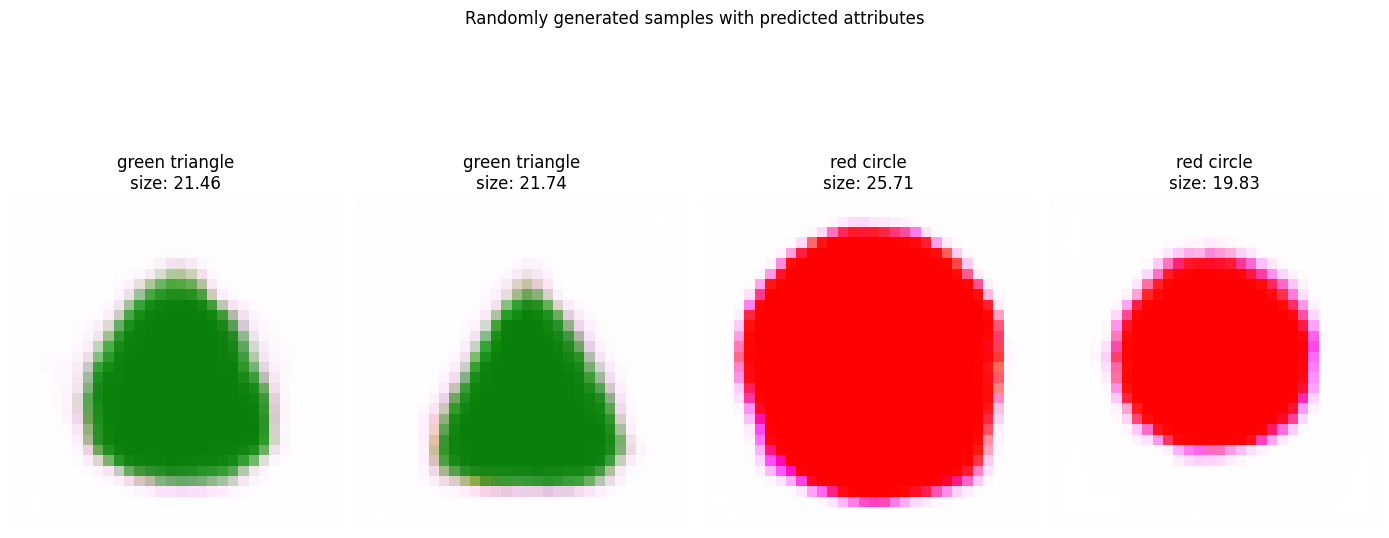

## **Petike letöltése**

In [ ]:
!gdown --id 1BVcLigJ5TOiQ2RIMiko47yYS8eUUtGme

/home/mimre/miniconda3/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1BVcLigJ5TOiQ2RIMiko47yYS8eUUtGme
To: /home/mimre/Git/ColorFullShapeVAE/cvae_model.pth
100%|██████████████████████████████████████| 1.89M/1.89M [00:00<00:00, 38.2MB/s]


## **Petike inicializálása**

In [ ]:
petike = Petike()
petike.load_state_dict(torch.load("cvae_model.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

# **Segédfüggvények**

In [ ]:
def image_to_tensor(img):
    """
    Convert a PIL image to a tensor and normalize it.
    Args:
        img (PIL.Image): Input image.
    Returns:
        torch.Tensor: Normalized tensor representation of the image with shape (B, C, H, W).
    """
    image = torch.tensor(np.array(img))
    image = image.permute(2, 0, 1).float() / 255.0
    return image.unsqueeze(0)  # Add batch dimension


def tensor_to_image(tensor):
    """
    Convert a tensor to a PIL image.
    Args:
        tensor (torch.Tensor): Input tensor with shape (B, C, H, W).
    Returns:
        PIL.Image: Image representation of the tensor.
    """
    image = tensor.squeeze(0).permute(1, 2, 0).clamp(0, 1).numpy()
    return Image.fromarray((image * 255).astype(np.uint8))


def draw_shape(shape, size, position, color):
    """
    Draw a shape on a blank image with size 32x32.
    Args:
        draw (PIL.ImageDraw): ImageDraw object to draw on.
        shape (str): Shape type ('triangle', 'square', 'circle').
        size (int): Size of the shape.
        position (tuple): Position (x, y) to draw the shape.
        color (tuple): Color of the shape (R, G, B) or string literals like ('red', 'blue', 'green').
    """
    image = Image.new("RGB", (32, 32), (255, 255, 255))
    draw = ImageDraw.Draw(image)
    x, y = position
    if shape == "triangle":
        points = [
            (x + size // 2, y),  # top
            (x, y + size),       # bottom left
            (x + size, y + size) # bottom right
        ]
        draw.polygon(points, fill=color)
    elif shape == "square":
        draw.rectangle([x, y, x + size, y + size], fill=color)
    elif shape == "circle":
        draw.ellipse([x, y, x + size, y + size], fill=color)

    return image


def reconstruct(model, batch):
    """
    Reconstruct the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images.
    Returns:
        torch.Tensor: Reconstructed images.
    """
    model.eval()
    with torch.no_grad():
        latent_vector = model.encode(batch)
        latent_vector = latent_vector[0].unsqueeze(0)
        recon = model.decode(latent_vector[0])

    return recon


def encode(model, batch):
    """
    Encode the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images with shape (B, C, H, W).
    Returns:
        torch.Tensor: Encoded latent vectors.
    """
    model.eval()
    with torch.no_grad():
        latent_vector = model.encode(batch)
        latent_vector = latent_vector[0].unsqueeze(0)

    return latent_vector


def decode(model, latent_vector):
    """
    Decode the latent vector using the loaded model.
    Args:
        latent_vector (torch.Tensor): Latent vector to decode with shape (B, 48).
    Returns:
        torch.Tensor: Reconstructed images.
    """
    model.eval()
    with torch.no_grad():
        recon = model.decode(latent_vector)

    return recon

# **Megoldás**

### **A narancssárga háromszög létrehozása (naiv megközelítés)**

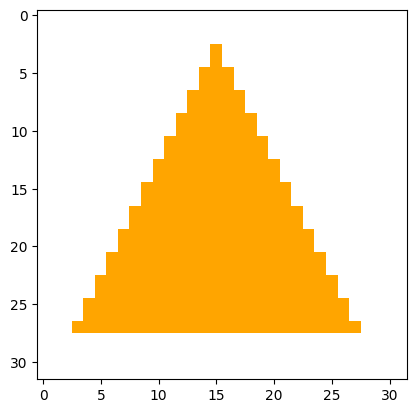

In [ ]:
# draw a red triangle
img = draw_shape("triangle", 24, (3, 3), (255, 165, 0))
plt.imshow(img)

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

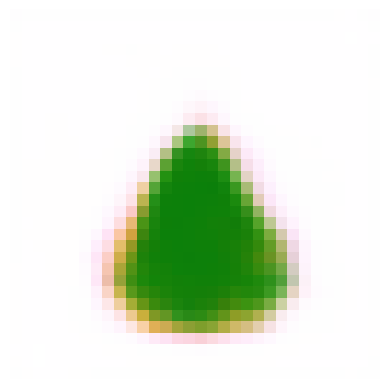

In [ ]:
img_tensor = image_to_tensor(img)

recon = reconstruct(petike, img_tensor)
recon_img = tensor_to_image(recon[0])
plt.imshow(recon_img)
plt.axis("off")

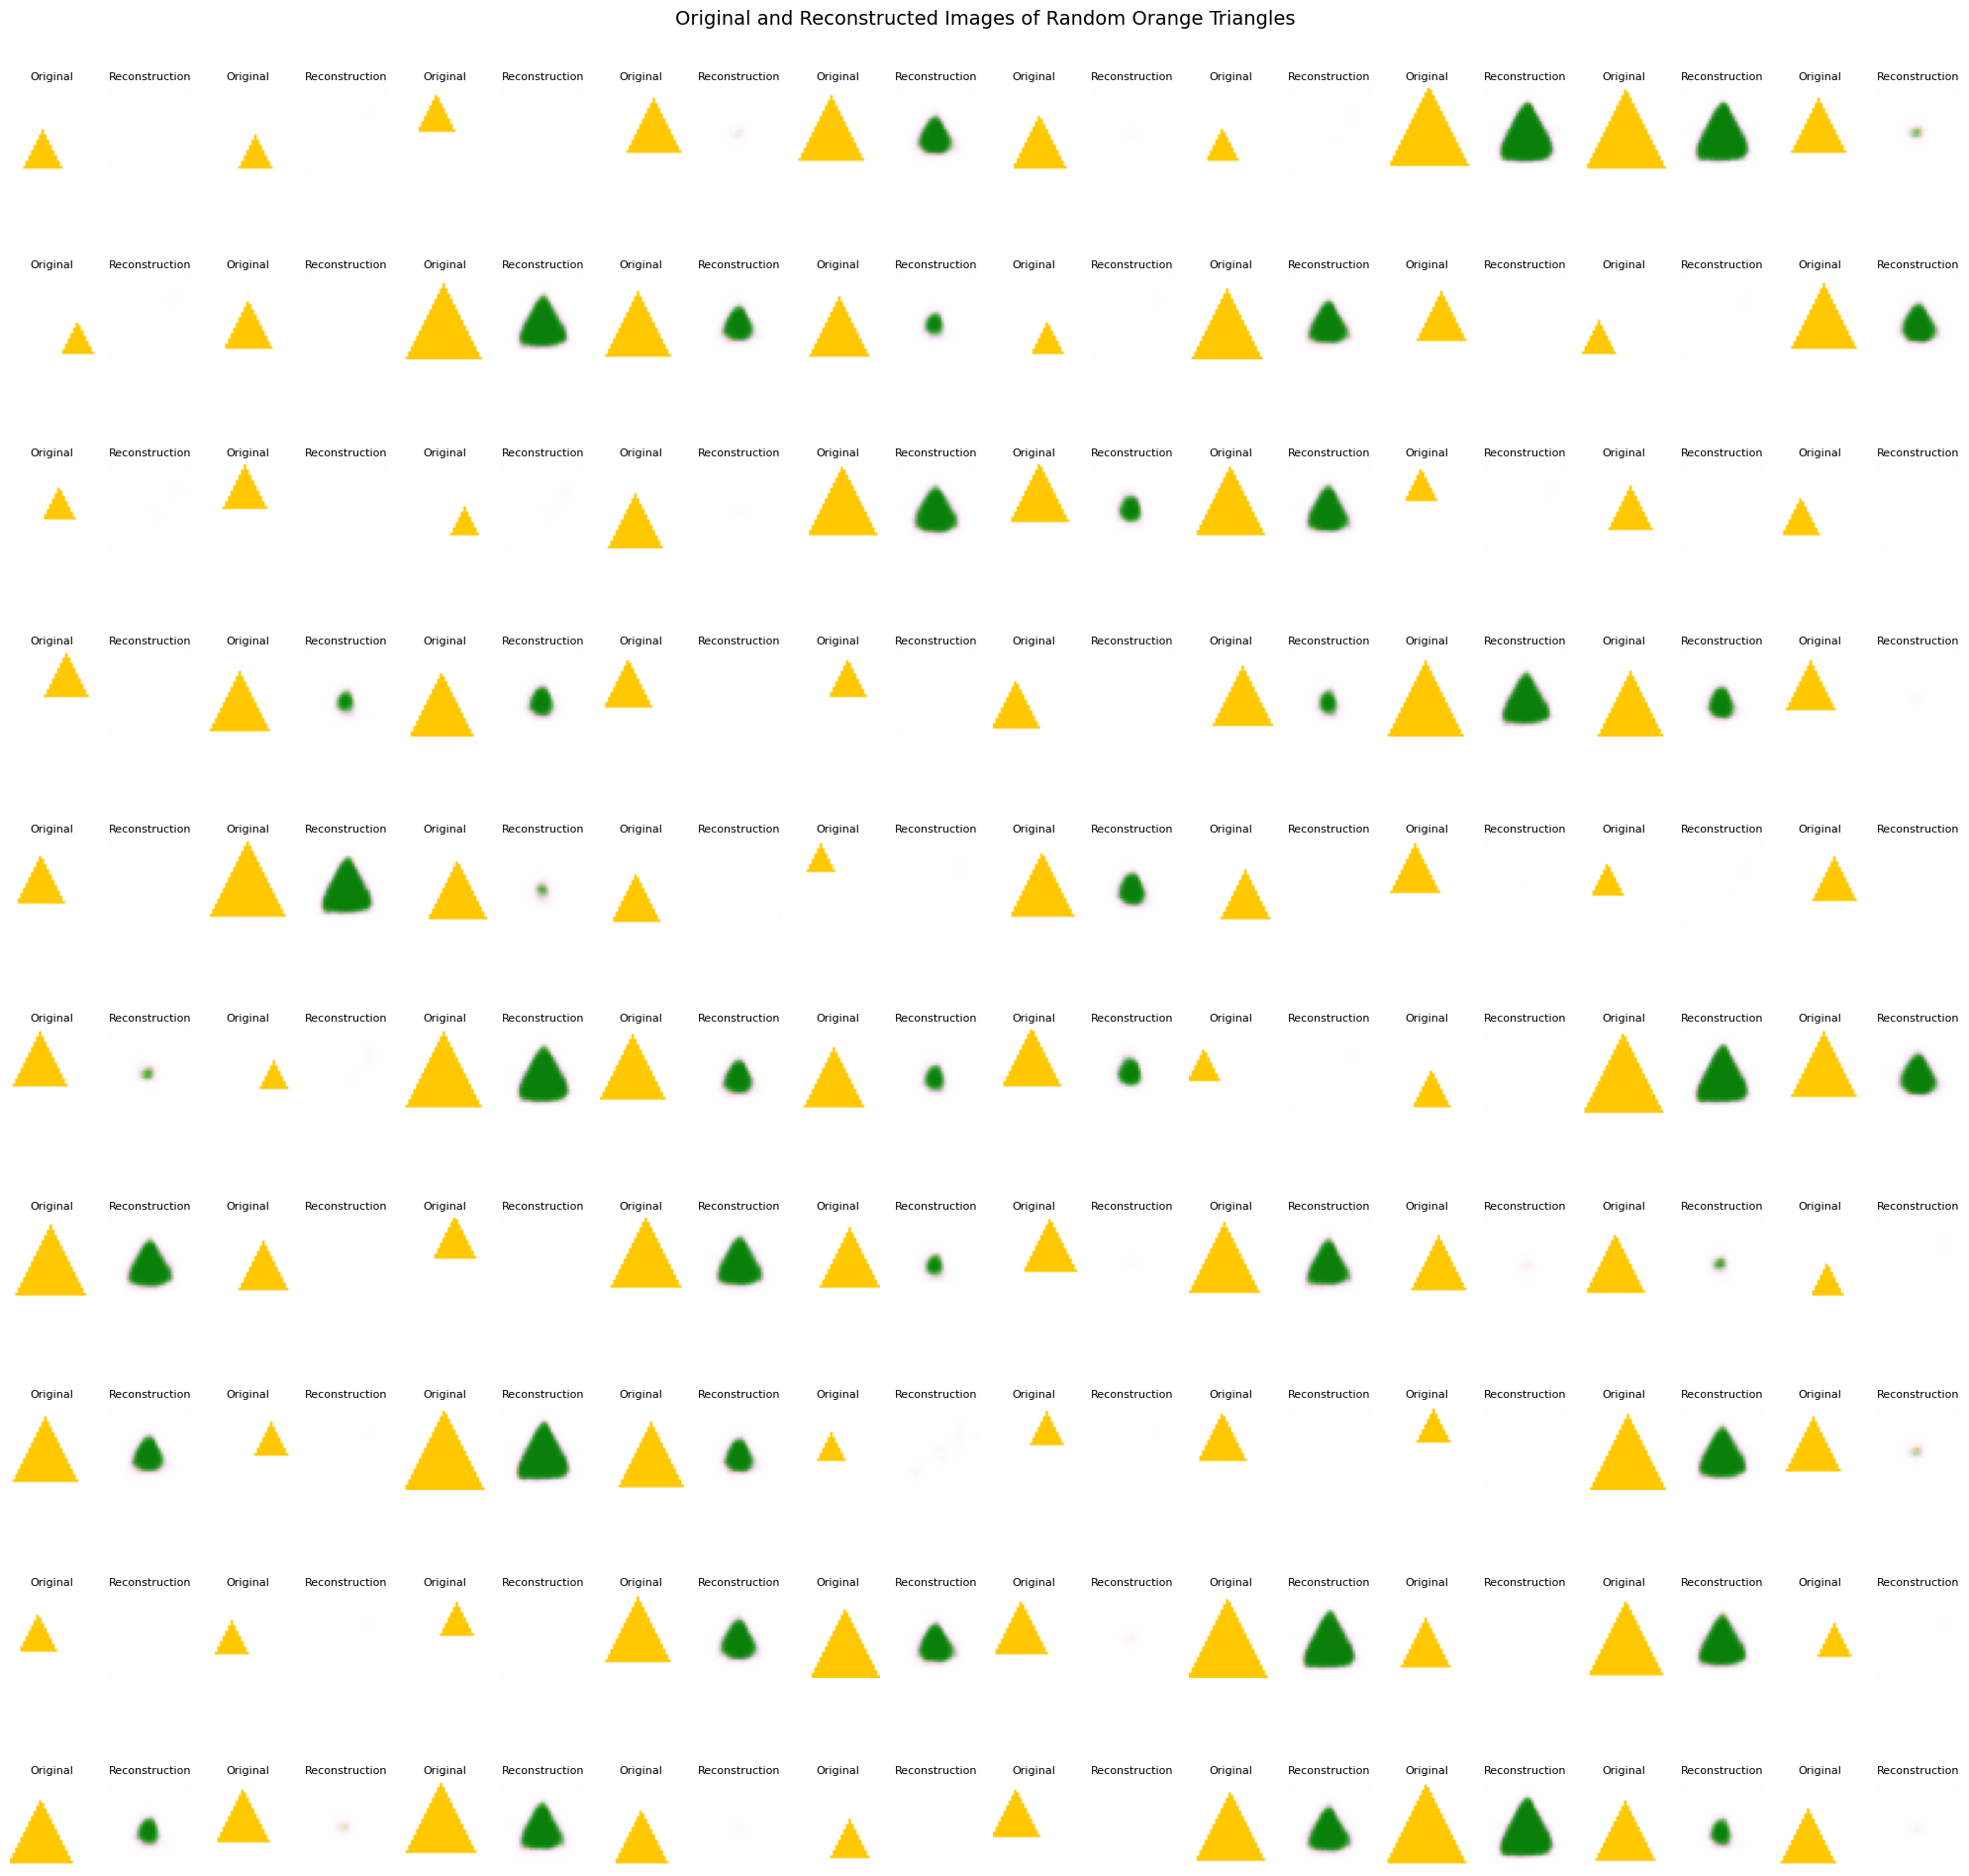

In [ ]:
# Parameters
num_samples = 100
images_per_row = 10
rows = num_samples // images_per_row

fig, axs = plt.subplots(rows, images_per_row * 2, figsize=(20, rows * 2))
axs = axs.flatten()

for i in range(num_samples):
    # Random size and position
    size = np.random.randint(10, 30)
    position = (np.random.randint(0, 32 - size), np.random.randint(0, 32 - size))

    # Generate image and reconstruction
    img = draw_shape("triangle", size, position, (255, 200, 0))  # orange
    img_tensor = image_to_tensor(img)
    recon = reconstruct(petike, img_tensor)
    recon_img = tensor_to_image(recon[0])

    # Plot original
    axs[i * 2].imshow(img)
    axs[i * 2].axis("off")
    axs[i * 2].set_title("Original", fontsize=8)

    # Plot reconstruction
    axs[i * 2 + 1].imshow(recon_img)
    axs[i * 2 + 1].axis("off")
    axs[i * 2 + 1].set_title("Reconstruction", fontsize=8)

plt.suptitle("Original and Reconstructed Images of Random Orange Triangles", fontsize=14)
plt.tight_layout()
plt.show()


### **Látens vektorok összemosásával**

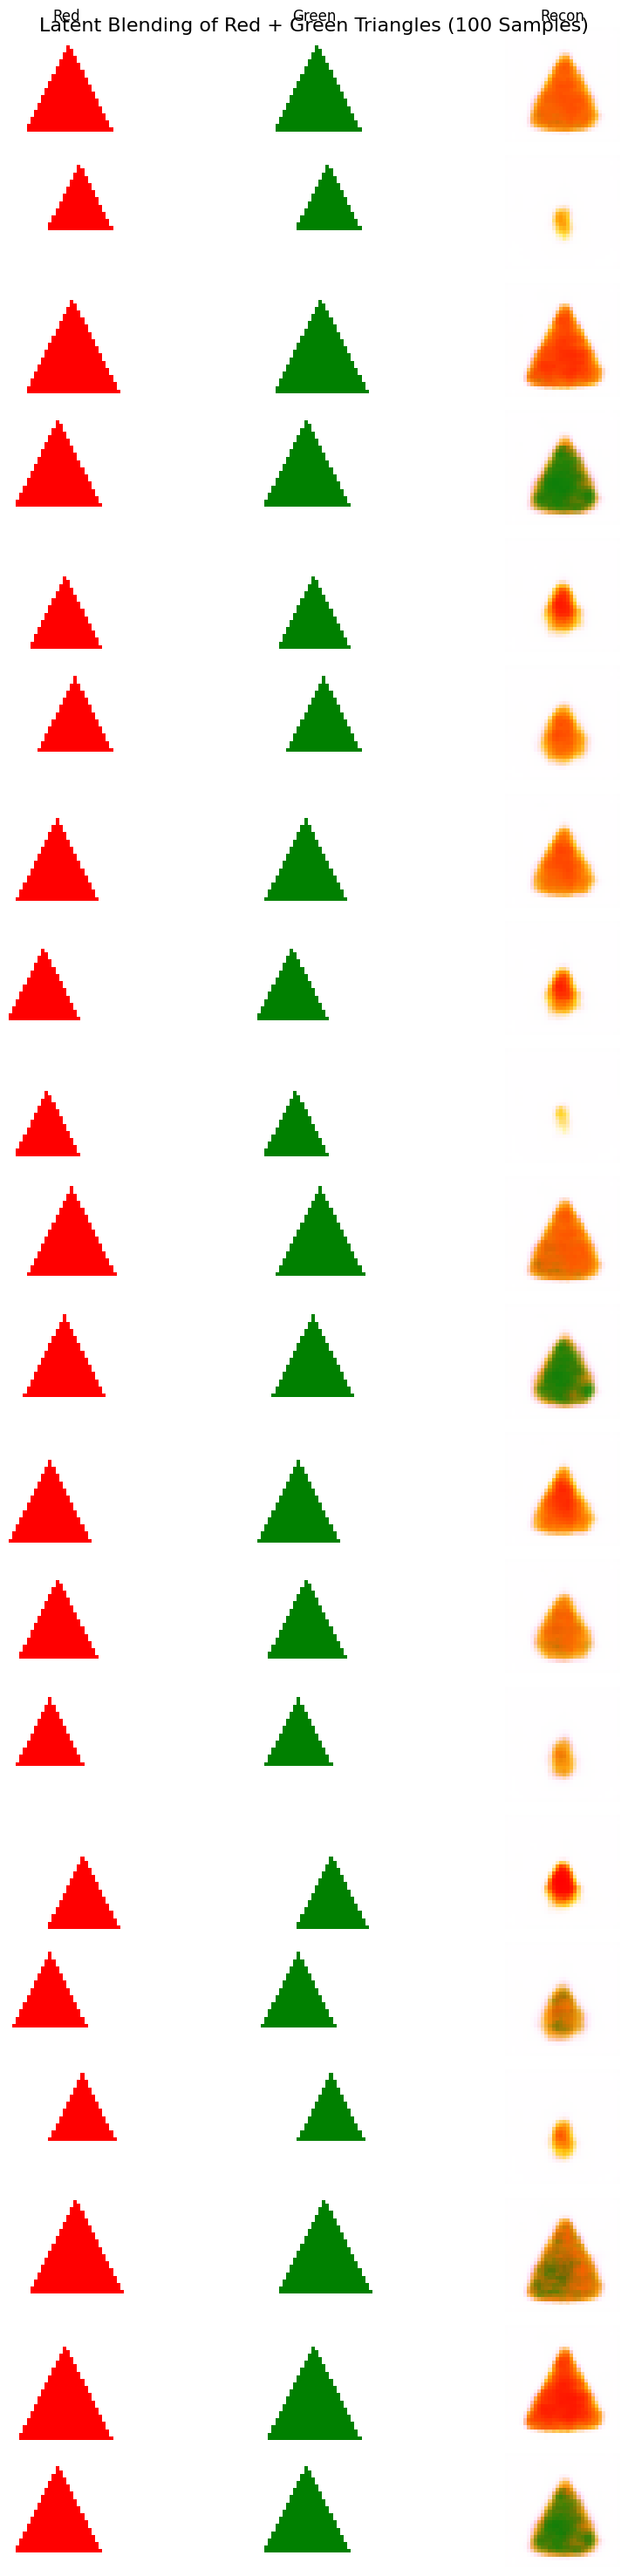

In [ ]:
# Parameters
num_samples = 20
images_per_row = 3  # red, green, reconstruction
rows = num_samples

fig, axs = plt.subplots(rows, images_per_row, figsize=(10, rows * 1.5))

for i in range(num_samples):
    # Random red triangle
    size1 = np.random.randint(16, 26)
    pos1 = (np.random.randint(0, 32 - size1), np.random.randint(0, 32 - size1))
    red_triangle = draw_shape("triangle", size1, pos1, (255, 0, 0))
    red_tensor = image_to_tensor(red_triangle)
    z_red = encode(petike, red_tensor)

    # Random green triangle
    green_triangle = draw_shape("triangle", size1, pos1, "green")
    green_tensor = image_to_tensor(green_triangle)
    z_green = encode(petike, green_tensor)

    # Average latent vector
    z_mix = (z_red + z_green) / 2
    recon_tensor = decode(petike, z_mix.squeeze(1))
    recon_img = tensor_to_image(recon_tensor)

    # Plot red triangle
    axs[i, 0].imshow(red_triangle)
    axs[i, 0].axis("off")
    if i == 0:
        axs[i, 0].set_title("Red")

    # Plot green triangle
    axs[i, 1].imshow(green_triangle)
    axs[i, 1].axis("off")
    if i == 0:
        axs[i, 1].set_title("Green")

    # Plot reconstruction
    axs[i, 2].imshow(recon_img)
    axs[i, 2].axis("off")
    if i == 0:
        axs[i, 2].set_title("Recon")

plt.suptitle("Latent Blending of Red + Green Triangles (100 Samples)", fontsize=16)
plt.tight_layout()
plt.show()


### **A narancssárga háromszög létrehozása (látens vectorok kombinálása)**

#### **Eredeti képek előkészítése**

In [ ]:
IMAGE_SIZE = 32

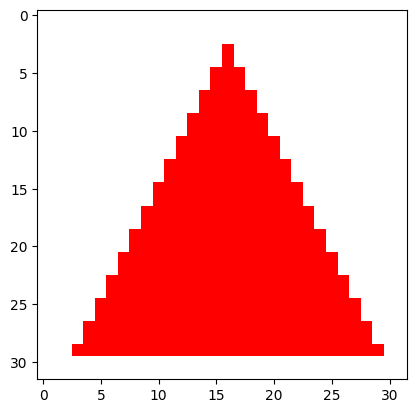

In [ ]:
x = IMAGE_SIZE // 2 - 13
y = IMAGE_SIZE // 2 - 13

triangle_r = draw_shape("triangle", 26, (x, y), "red")
plt.imshow(triangle_r)

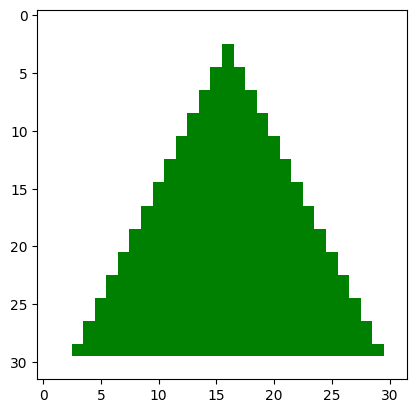

In [ ]:
x = IMAGE_SIZE // 2 - 13
y = IMAGE_SIZE // 2 - 13

triangle_g = draw_shape("triangle", 26, (x, y), "green")
plt.imshow(triangle_g)

#### **Látens vektorok kombinálása**

torch.Size([1, 2, 48])
torch.Size([1, 48])


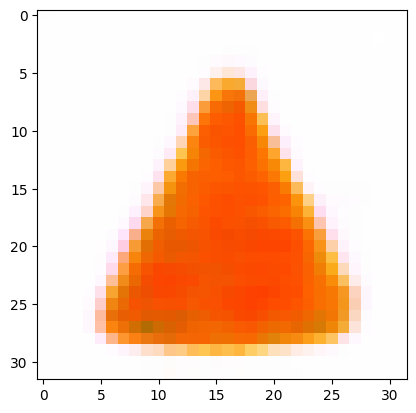

In [ ]:
batch = torch.cat([image_to_tensor(triangle_r), image_to_tensor(triangle_g)], dim=0)

latent_vector = encode(petike, batch)
print(latent_vector.shape)
latent_vector = latent_vector.mean(dim=1).squeeze(1)
print(latent_vector.shape)
recon = decode(petike, latent_vector)
recon_img = tensor_to_image(recon)
plt.imshow(recon_img)

torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 684)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 686)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 689)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 690)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 693)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 696)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 702)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 707)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 710)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 712)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 713)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 721)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 732)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 736)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 742)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 743)
torch.Size([1, 3, 32, 32])
(3, 32, 32)
(32, 32)
(3, 745)
torch.Size([1, 3, 32, 32])
(3, 

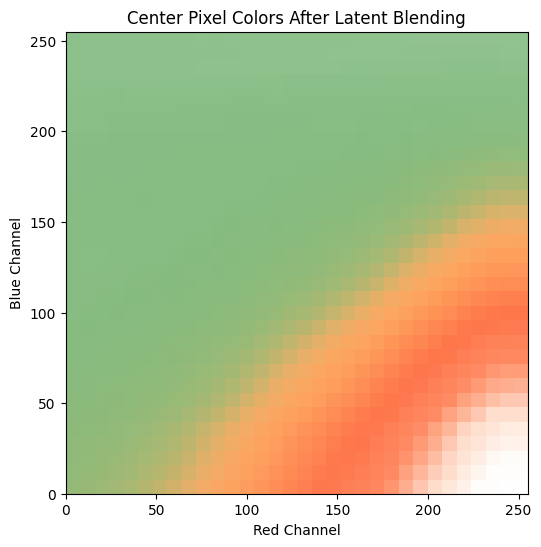

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid resolution
n_steps = 32  # 32x32 = 1024 total samples
r_vals = np.linspace(0, 255, n_steps).astype(int)
g_vals = np.linspace(0, 255, n_steps).astype(int)

canvas = np.zeros((n_steps, n_steps, 3))  # to hold RGB values of center pixel

for i, r in enumerate(r_vals):
    for j, g in enumerate(g_vals):
        size = 20
        pos = (6, 6)

        # Generate red square with current red value
        red_color = (r, 0, 0)
        red_img = draw_shape("square", size, pos, red_color)
        red_tensor = image_to_tensor(red_img)
        z_red = encode(petike, red_tensor)

        # Generate green square with current green value
        green_color = (0, g, 0)
        green_img = draw_shape("square", size, pos, green_color)
        green_tensor = image_to_tensor(green_img)
        z_green = encode(petike, green_tensor)

        # Blend and decode
        z_mix = (z_red + z_green) / 2
        recon_tensor = decode(petike, z_mix.squeeze(1))
        avg_color = recon_tensor.mean(dim=(2,3)).unsqueeze(0)
        recon_numpy = recon_tensor.squeeze(0).numpy()
        not_white = np.all(recon_numpy != 1, axis=0)
        colors = recon_numpy[:,not_white]
        avg_color = colors.mean(axis=1)

        canvas[j, i] = avg_color  # Note: j as row, i as column

# Show result as image
plt.figure(figsize=(6, 6))
plt.imshow(canvas, origin="lower", extent=[0, 255, 0, 255])
plt.xlabel("Red Channel")
plt.ylabel("Blue Channel")
plt.title("Center Pixel Colors After Latent Blending")
plt.show()


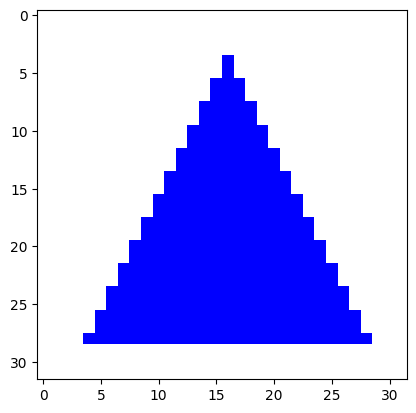

In [ ]:
plt.imshow(draw_shape("triangle", 24, (4, 4), (0, 0, 255)))  # blue

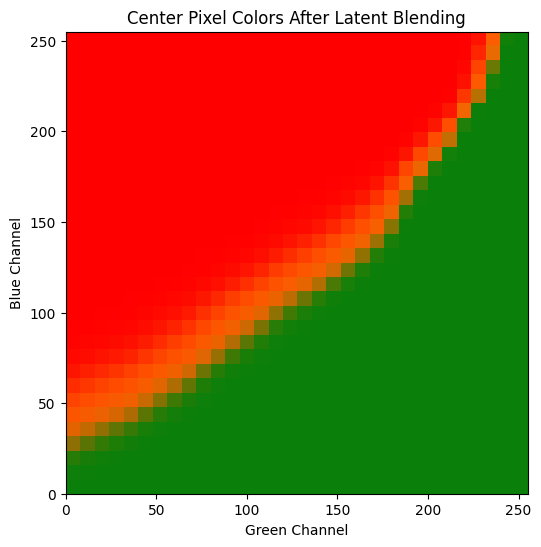

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid resolution
n_steps = 32  # 32x32 = 1024 total samples
g_vals = np.linspace(0, 255, n_steps).astype(int)
b_vals = np.linspace(0, 255, n_steps).astype(int)

canvas = np.zeros((n_steps, n_steps, 3))  # to hold RGB values of center pixel

for i, g in enumerate(g_vals):
    for j, b in enumerate(b_vals):
        size = 24
        pos = (4, 4)

        # Generate red square with current red value
        green_color = (0, g, 0)
        green_image = draw_shape("triangle", size, pos, green_color)
        green_tensor = image_to_tensor(green_image)
        z_green = encode(petike, green_tensor)

        # Generate blue square with current blue value
        blue_color = (0, 0, b)
        blue_img = draw_shape("triangle", size, pos, blue_color)
        blue_tensor = image_to_tensor(blue_img)
        z_blue = encode(petike, blue_tensor)

        # Blend and decode
        z_mix = (z_green + z_blue) / 2
        recon_tensor = decode(petike, z_mix.squeeze(1))
        recon_img = tensor_to_image(recon_tensor)

        # Get center pixel
        center_pixel = recon_img.getpixel((16, 16))
        center_pixel = np.array(center_pixel) / 255.0
        canvas[j, i] = center_pixel  # Note: j as row, i as column

# Show result as image
plt.figure(figsize=(6, 6))
plt.imshow(canvas, origin="lower", extent=[0, 255, 0, 255])
plt.xlabel("Green Channel")
plt.ylabel("Blue Channel")
plt.title("Center Pixel Colors After Latent Blending")
plt.show()


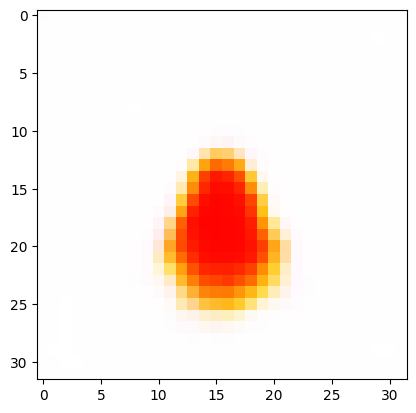

In [ ]:
size = 20
pos = (6, 6)

# Generate red square with current red value
green_color = (0, 220, 0)
green_image = draw_shape("triangle", size, pos, green_color)
green_tensor = image_to_tensor(green_image)
z_green = encode(petike, green_tensor)

# Generate blue square with current blue value
blue_color = (0, 0, 250)
blue_img = draw_shape("triangle", size, pos, blue_color)
blue_tensor = image_to_tensor(blue_img)
z_blue = encode(petike, blue_tensor)

# Blend and decode
z_mix = (z_green + z_blue) / 2
recon_tensor = decode(petike, z_mix.squeeze(1))
recon_img = tensor_to_image(recon_tensor)

plt.imshow(recon_img)

### **Magenta kör létrehozása (naiv megközelítés)**

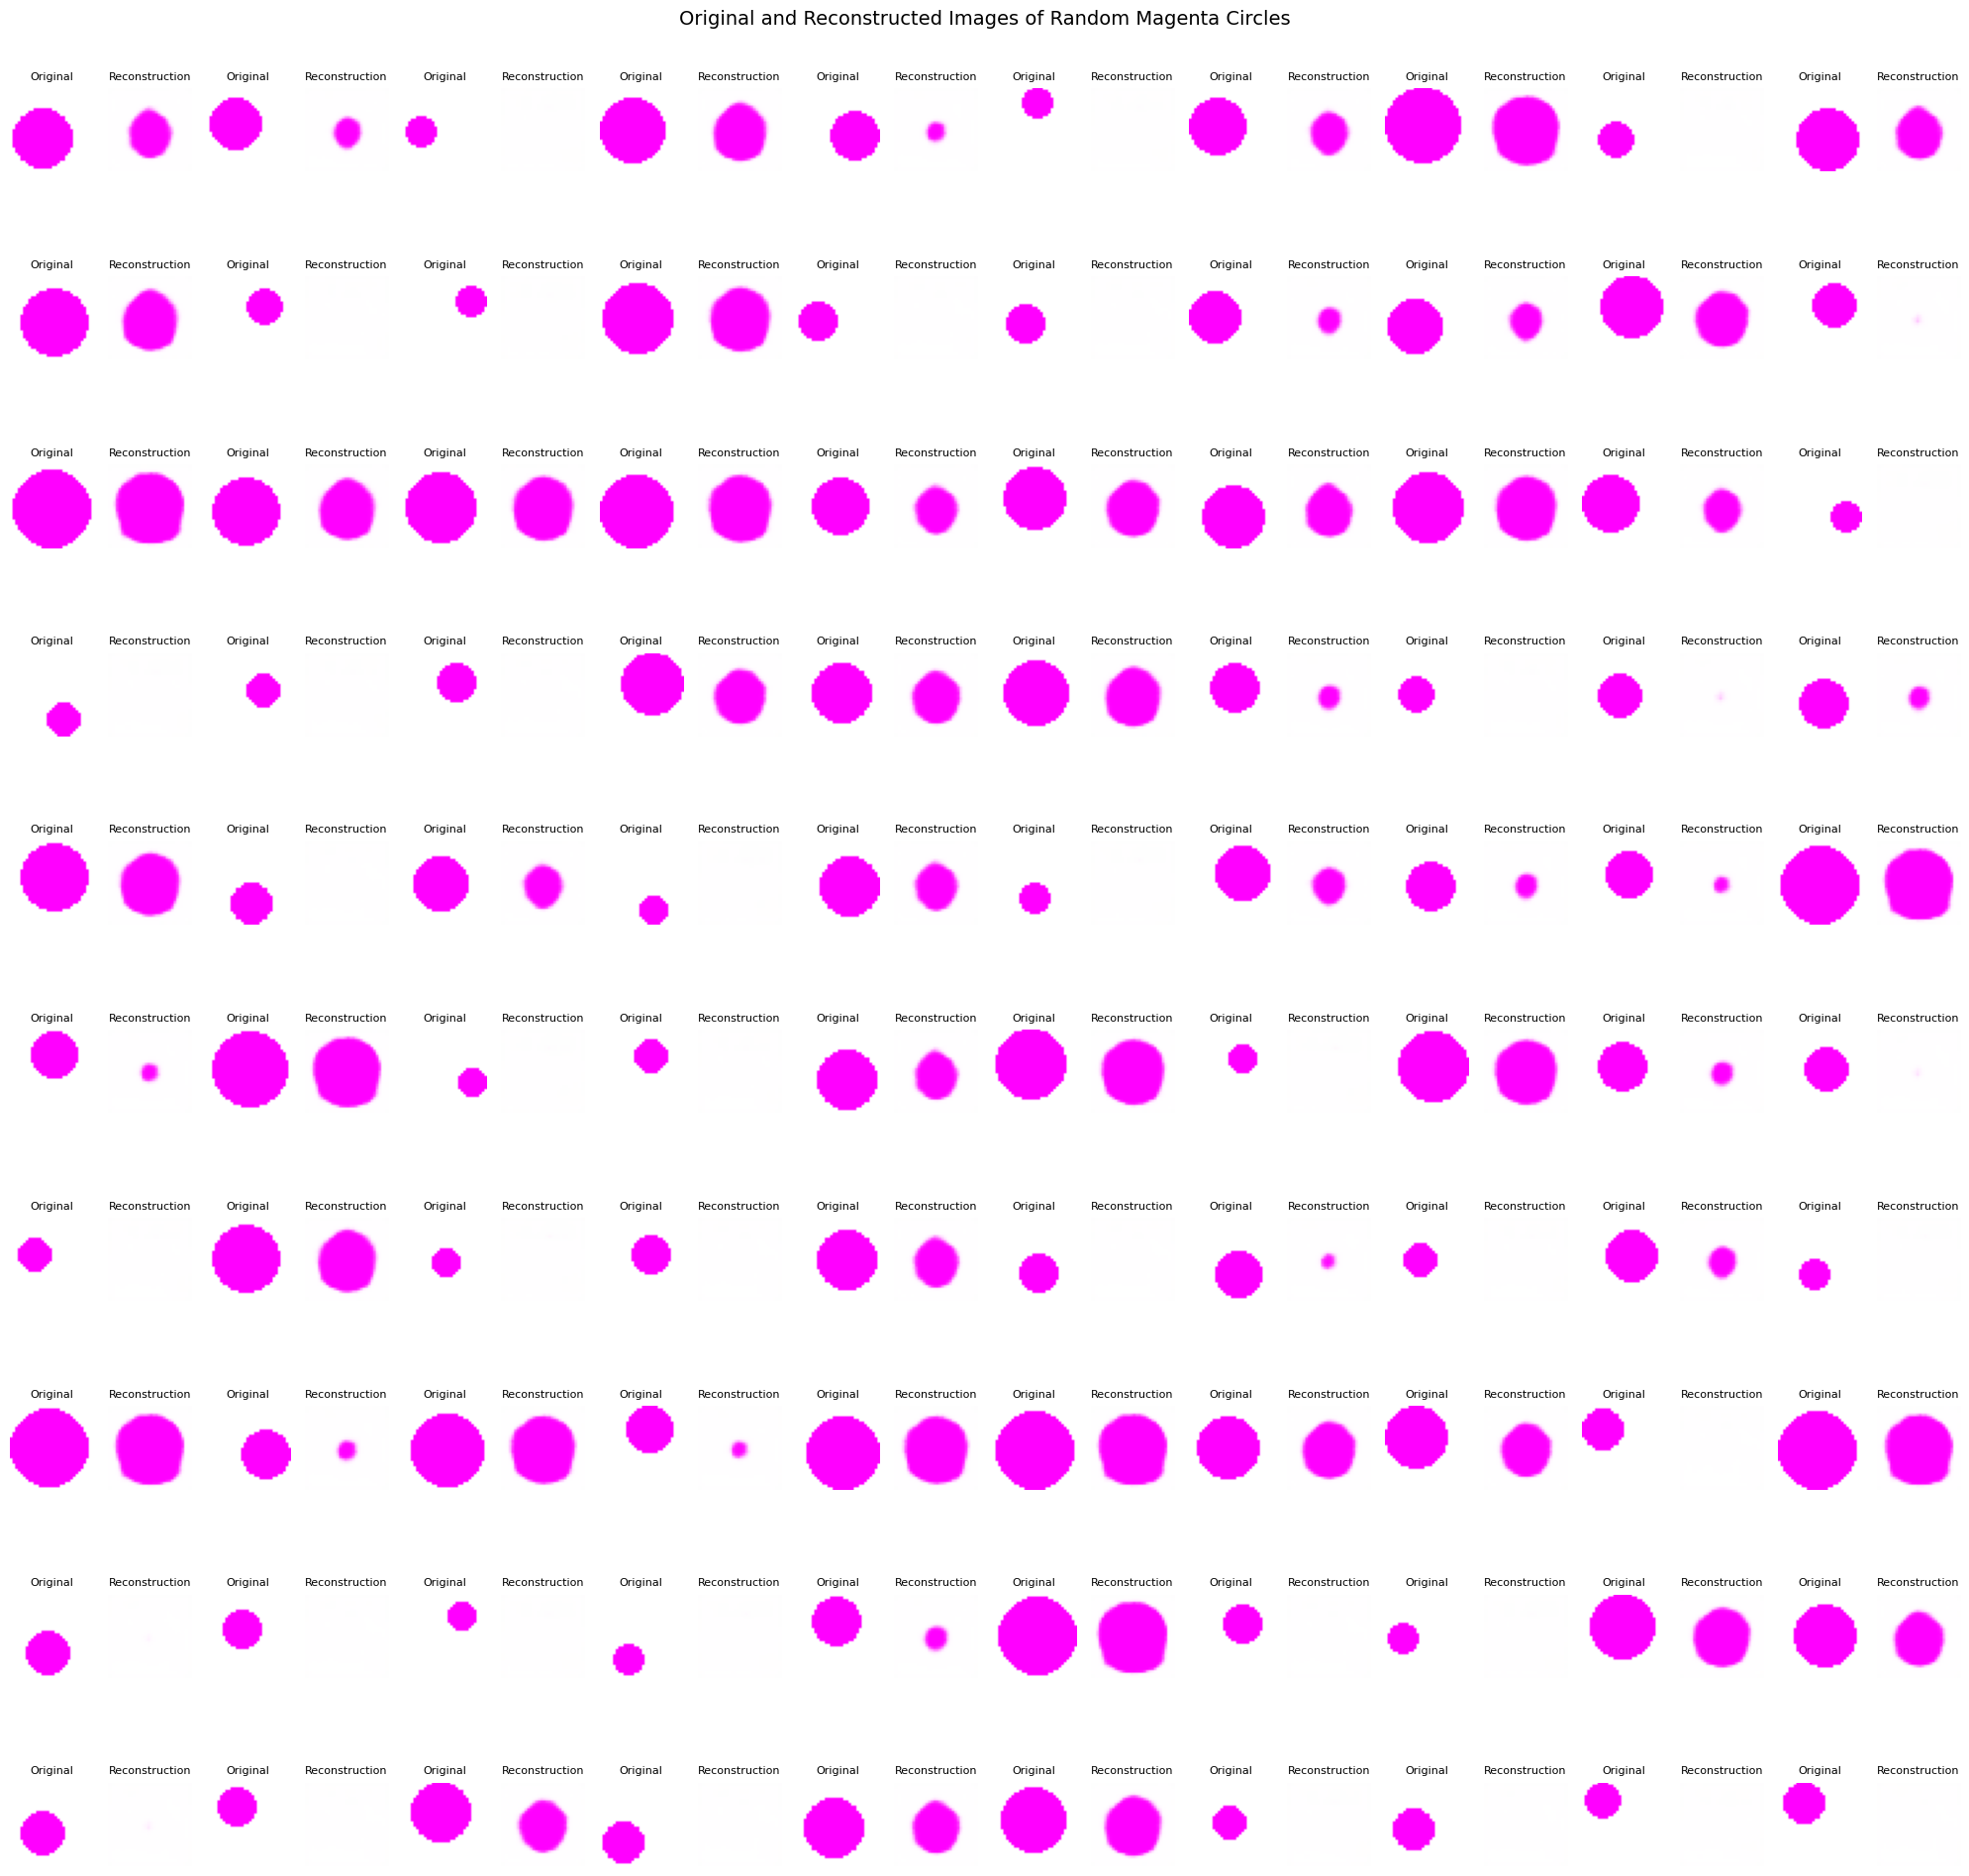

In [ ]:
# Parameters
num_samples = 100
images_per_row = 10
rows = num_samples // images_per_row

fig, axs = plt.subplots(rows, images_per_row * 2, figsize=(20, rows * 2))
axs = axs.flatten()

for i in range(num_samples):
    # Random size and position
    size = np.random.randint(10, 30)
    position = (np.random.randint(0, 32 - size), np.random.randint(0, 32 - size))

    # Generate image and reconstruction
    img = draw_shape("circle", size, position, (255, 0, 255))  # orange
    img_tensor = image_to_tensor(img)
    recon = reconstruct(petike, img_tensor)
    recon_img = tensor_to_image(recon[0])

    # Plot original
    axs[i * 2].imshow(img)
    axs[i * 2].axis("off")
    axs[i * 2].set_title("Original", fontsize=8)

    # Plot reconstruction
    axs[i * 2 + 1].imshow(recon_img)
    axs[i * 2 + 1].axis("off")
    axs[i * 2 + 1].set_title("Reconstruction", fontsize=8)

plt.suptitle("Original and Reconstructed Images of Random Magenta Circles", fontsize=14)
plt.tight_layout()
plt.show()


#### **Magenta körök létrehozása (látens vektorok összemosásával)**

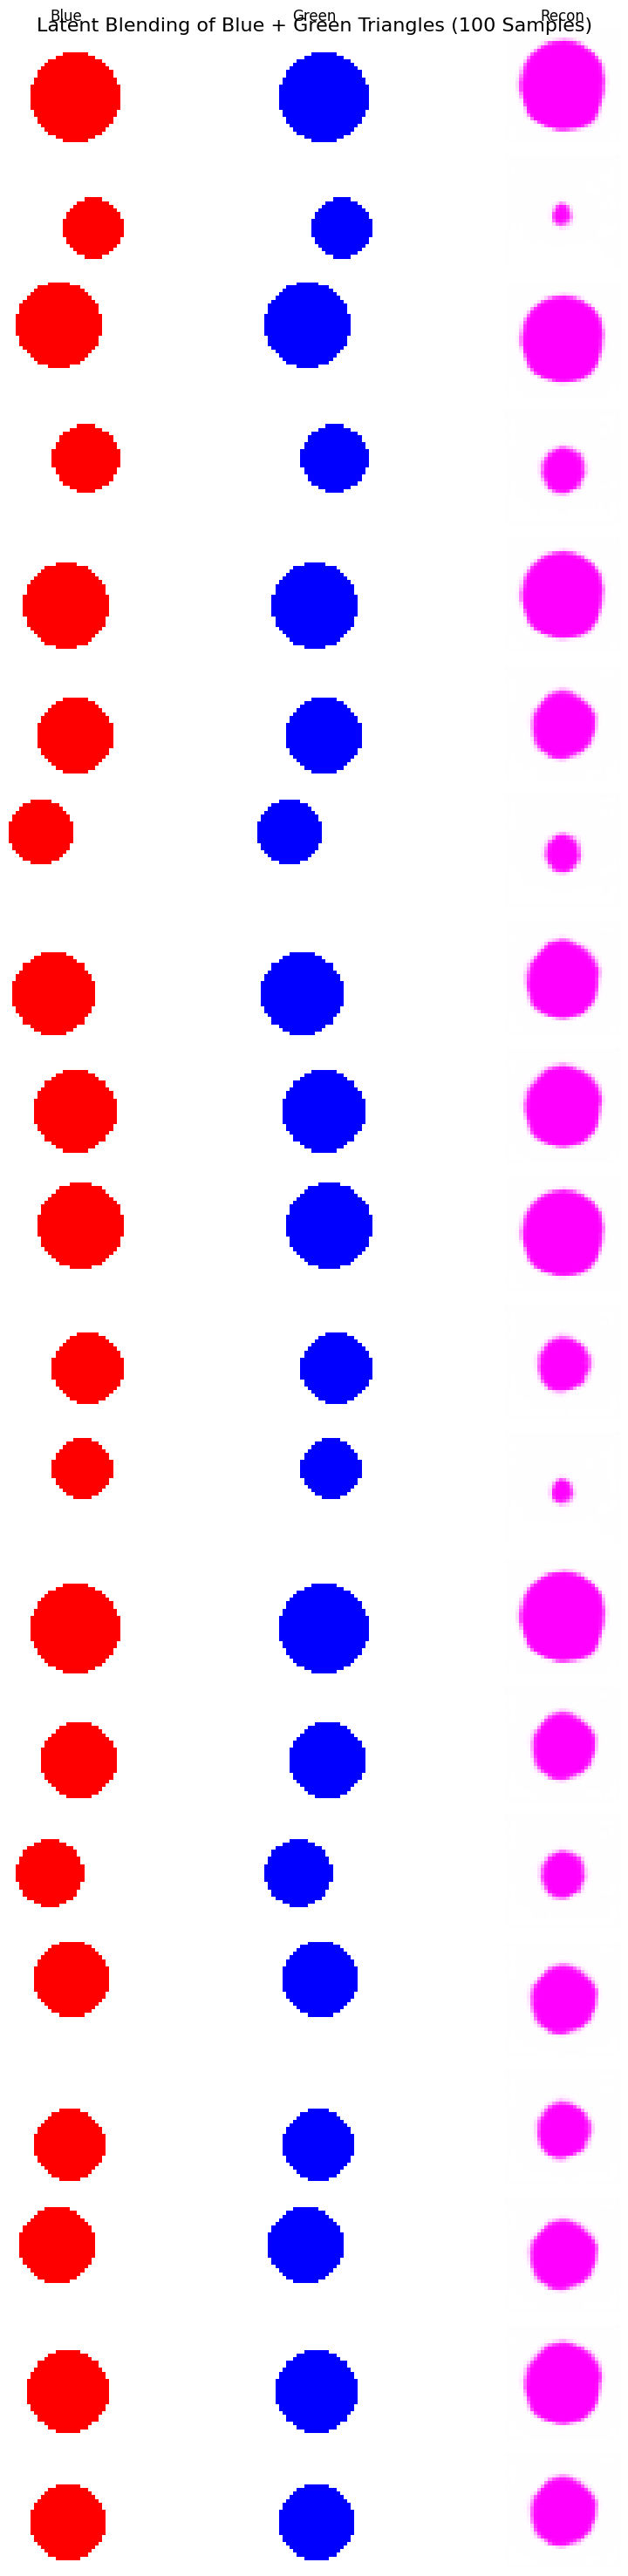

In [ ]:
# Parameters
num_samples = 20
images_per_row = 3  # red, green, reconstruction
rows = num_samples

fig, axs = plt.subplots(rows, images_per_row, figsize=(10, rows * 1.5))

for i in range(num_samples):
    # Random red triangle
    size1 = np.random.randint(16, 26)
    pos1 = (np.random.randint(0, 32 - size1), np.random.randint(0, 32 - size1))
    blue_triangle = draw_shape("circle", size1, pos1, "red")
    blue_tensor = image_to_tensor(blue_triangle)
    z_blue = encode(petike, blue_tensor)

    # Random green triangle
    green_triangle = draw_shape("circle", size1, pos1, "blue")
    green_tensor = image_to_tensor(green_triangle)
    z_green = encode(petike, green_tensor)

    # Average latent vector
    z_mix = (z_blue + z_green) / 2
    recon_tensor = decode(petike, z_mix.squeeze(1))
    recon_img = tensor_to_image(recon_tensor)

    # Plot blue triangle
    axs[i, 0].imshow(blue_triangle)
    axs[i, 0].axis("off")
    if i == 0:
        axs[i, 0].set_title("Blue")

    # Plot green triangle
    axs[i, 1].imshow(green_triangle)
    axs[i, 1].axis("off")
    if i == 0:
        axs[i, 1].set_title("Green")

    # Plot reconstruction
    axs[i, 2].imshow(recon_img)
    axs[i, 2].axis("off")
    if i == 0:
        axs[i, 2].set_title("Recon")

plt.suptitle("Latent Blending of Blue + Green Triangles (100 Samples)", fontsize=16)
plt.tight_layout()
plt.show()


### **Képek generálása kék foltokkal**

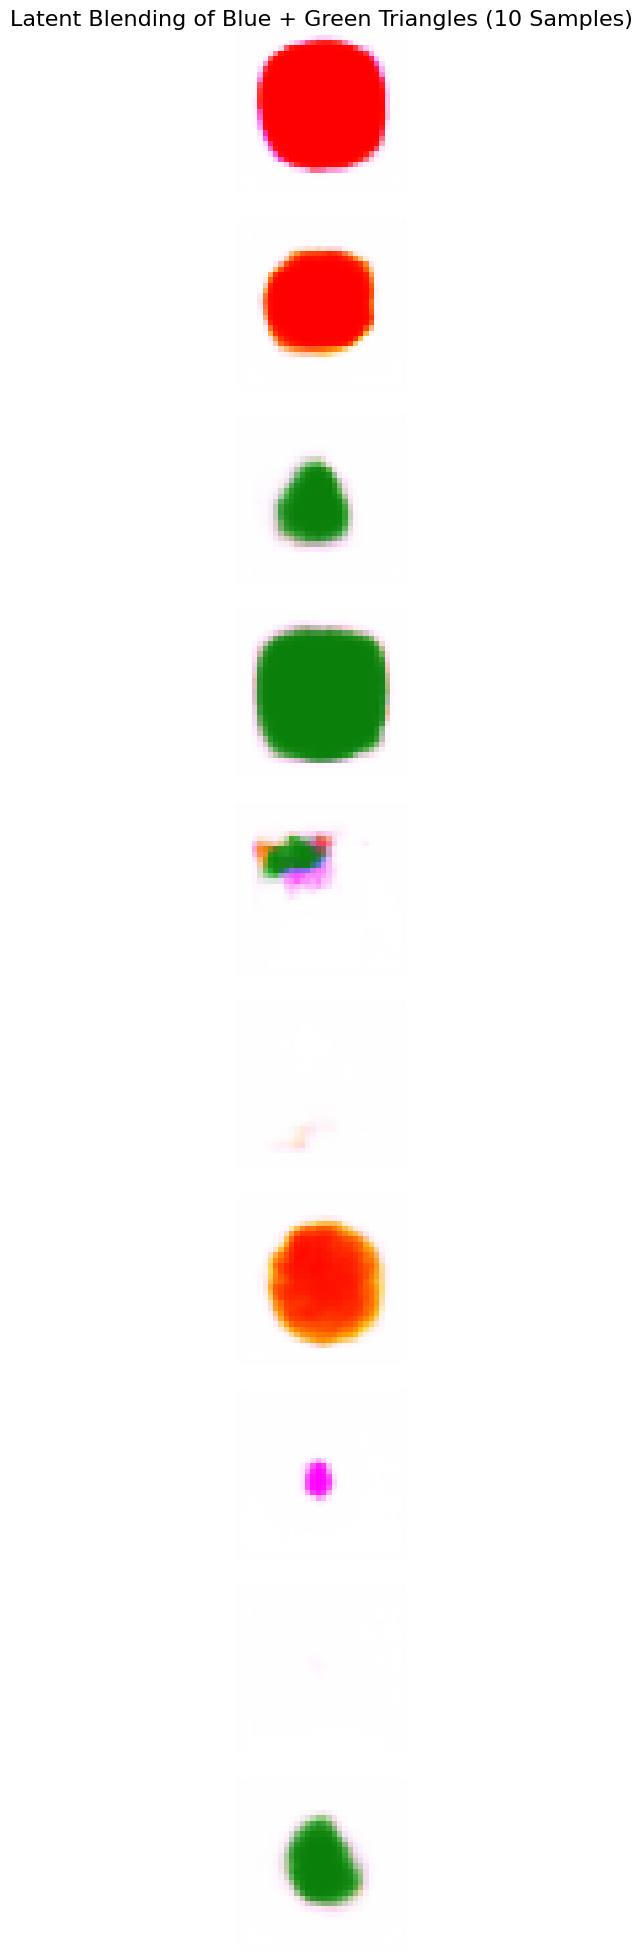

In [ ]:
# Parameters
num_samples = 10
images_per_row = 3  # red, green, reconstruction
rows = num_samples

fig, axs = plt.subplots(rows, figsize=(2, rows * 2))

for i in range(num_samples):
    # Random latent vector
    latent_vector = torch.randn(1, LATENT_FEATURE_SIZE)
    # latent_vector[0, 0:24] = latent_vector[0, 0:24] * 10  # Set shape features to 0
    # latent_vector[0, 24:48] =  latent_vector[0, 24:48] * 0  # Set color features to 0
    recon_tensor = decode(petike, latent_vector.squeeze(1))
    recon_img = tensor_to_image(recon_tensor)

    # Plot reconstruction
    axs[i].imshow(recon_img)
    axs[i].axis("off")

plt.suptitle("Latent Blending of Blue + Green Triangles (10 Samples)", fontsize=16)
plt.tight_layout()
plt.show()

### **Az egyes látens dimenziók végigpróbálgatása, melyik befolyásolja a kép színét nagyban**

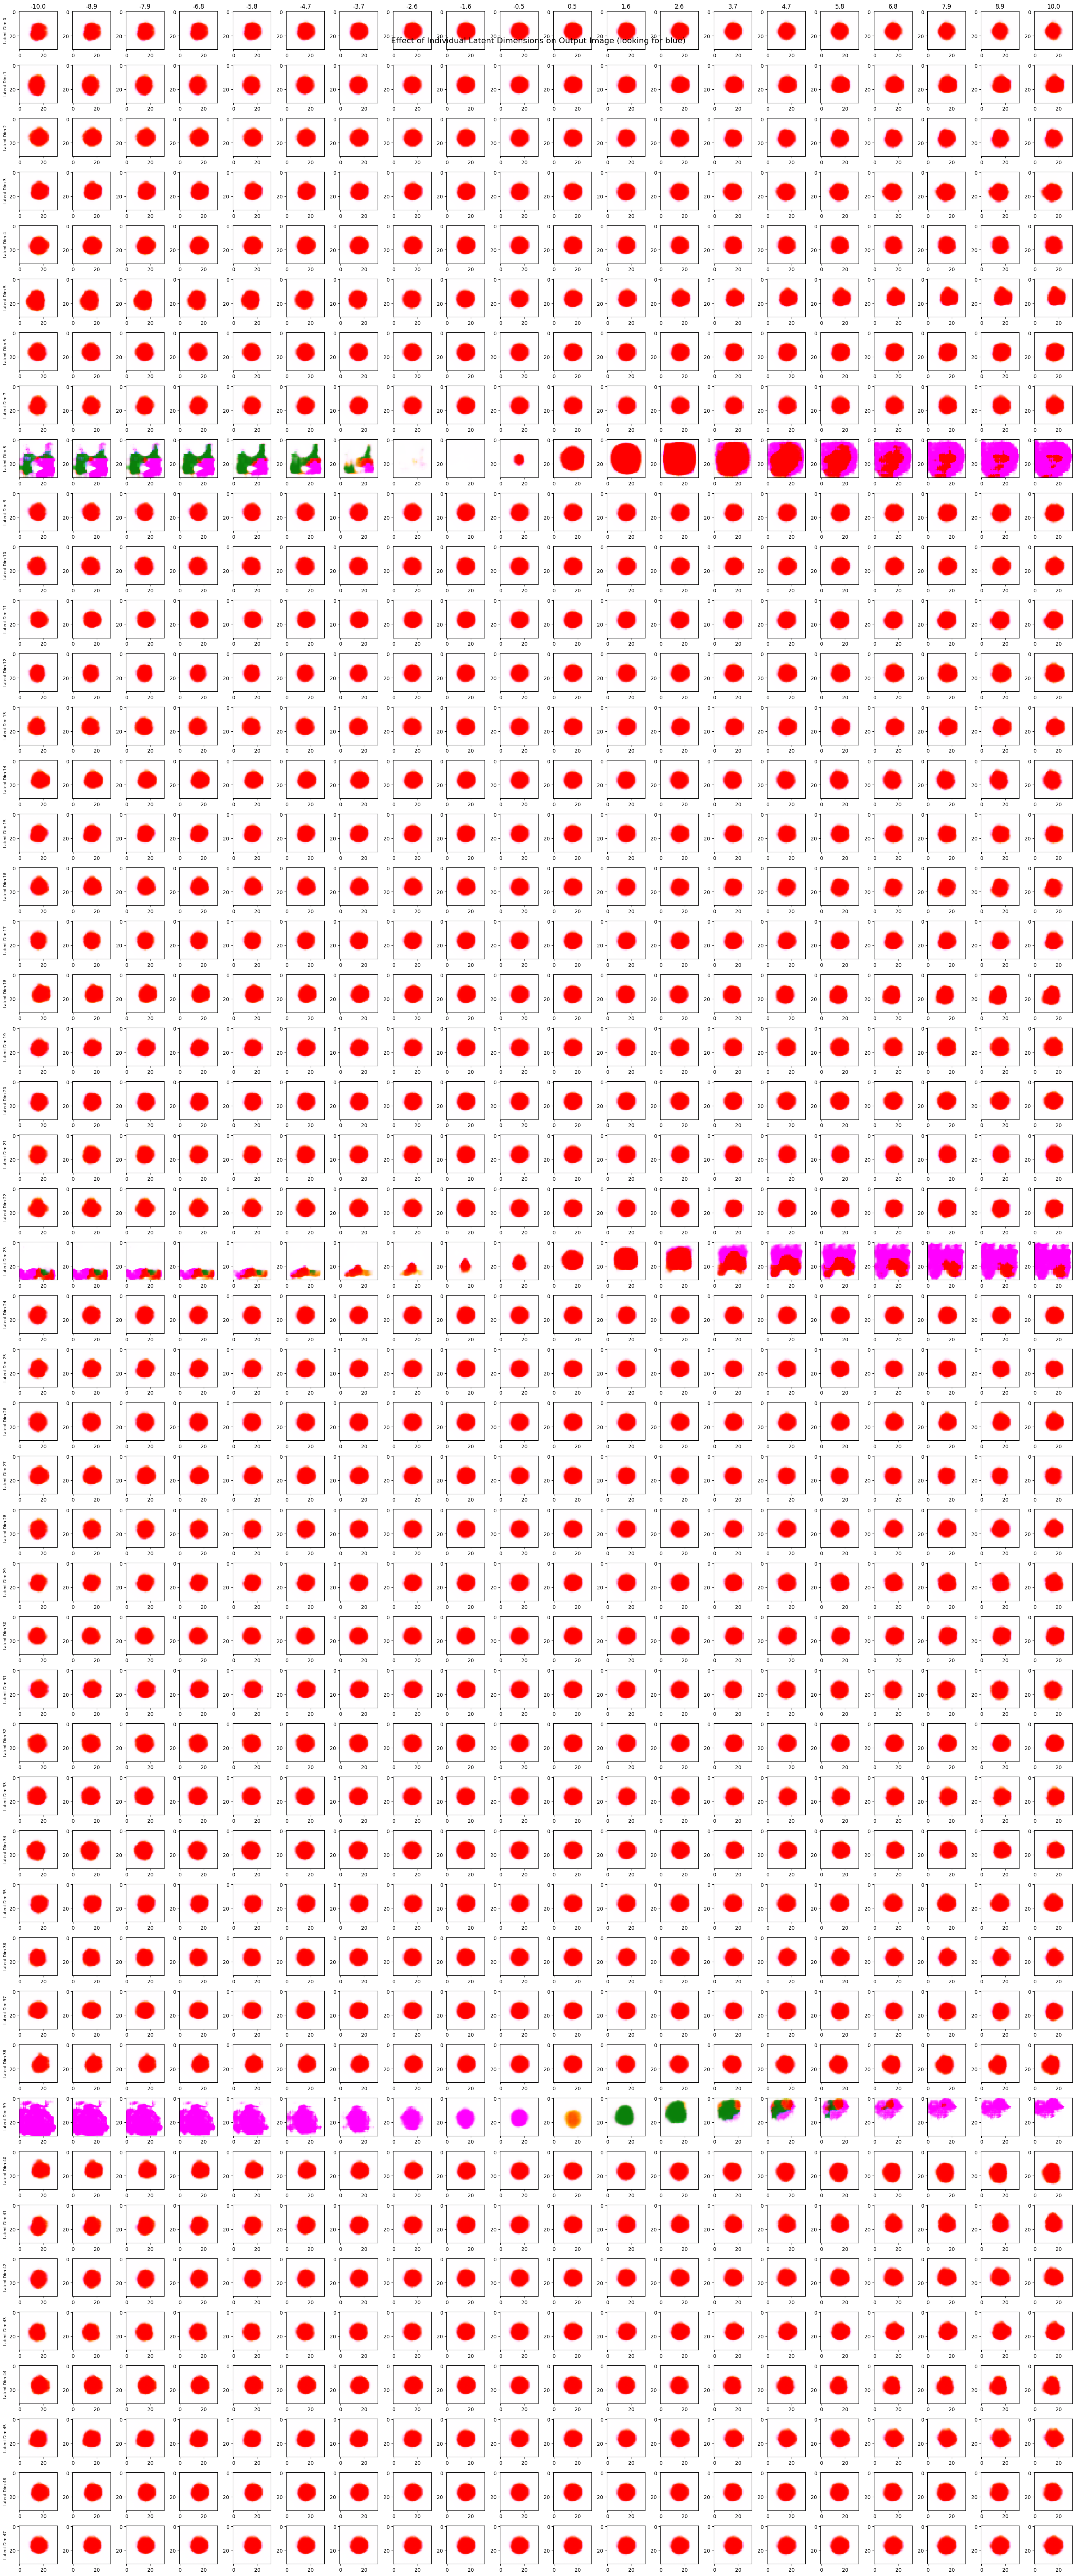

In [ ]:

steps = 20  # how many values to test per dimension
value_range = torch.linspace(-10, 10, steps)

# Set base latent vector
base_latent = torch.zeros(1, LATENT_FEATURE_SIZE)

# Create figure
fig, axs = plt.subplots(LATENT_FEATURE_SIZE, steps, figsize=(steps * 1.5, LATENT_FEATURE_SIZE * 1.5))

for dim in range(LATENT_FEATURE_SIZE):
    axs[dim, 0].set_ylabel(f"Latent Dim {dim}", fontsize=8)
    for i, val in enumerate(value_range):
        latent = base_latent.clone()
        latent[0, dim] = val  # only vary one dimension
        output = decode(petike, latent)
        img = tensor_to_image(output)

        axs[dim, i].imshow(img)

        if dim == 0:
            axs[dim, i].set_title(f"{val:.1f}")

plt.suptitle("Effect of Individual Latent Dimensions on Output Image (looking for blue)", fontsize=16)
plt.tight_layout()
plt.show()


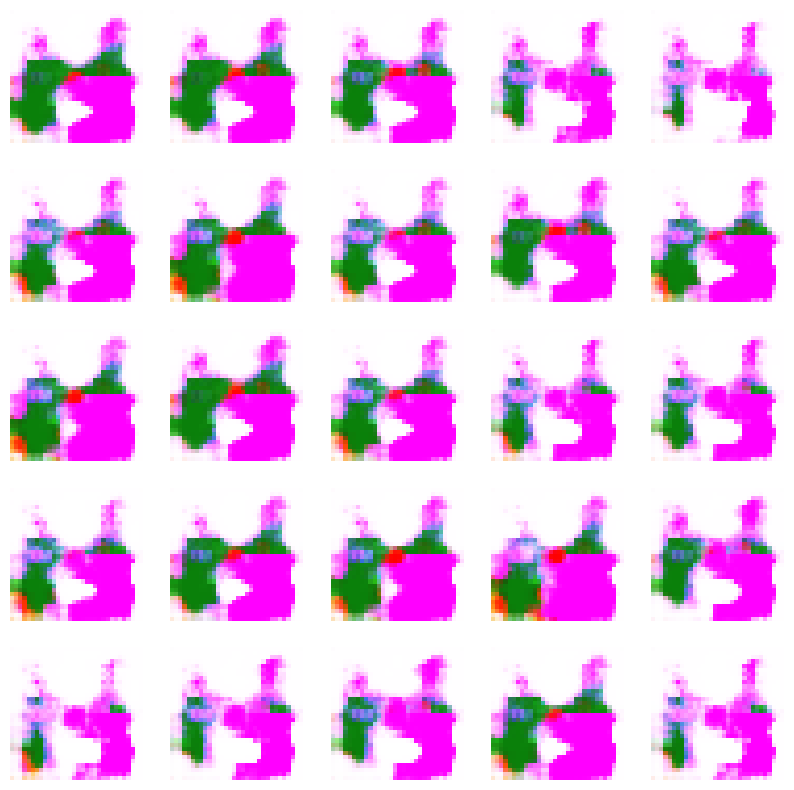

In [ ]:
# plot images in a 5x5 grid
fig, axs = plt.subplots(5, 5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        # Random size and position
        latent_vector = torch.randn(1, LATENT_FEATURE_SIZE)
        latent_vector[:, 8] = -10

        recon = decode(petike, latent_vector)
        recon_img = tensor_to_image(recon[0])

        axs[i, j].imshow(recon_img)
        axs[i, j].axis("off")